In [1]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import pandas as pd

In [8]:
%pip install lime


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare the data

In [3]:
df = pd.read_csv(r"../data/adult_income.csv")

In [4]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe(include='all'))

# Check target distribution
print(df.columns.tolist())


(1664500, 12)
   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P   ST    PINCP
0  18.0  1.0  18.0  5.0  4720.0  13.0  17.0  21.0  2.0    2.0  1.0   1600.0
1  53.0  5.0  17.0  5.0  3605.0  18.0  16.0  40.0  1.0    1.0  1.0  10000.0
2  41.0  1.0  16.0  5.0  7330.0   1.0  17.0  40.0  1.0    1.0  1.0  24000.0
3  18.0  6.0  18.0  5.0  2722.0   1.0  17.0   2.0  2.0    1.0  1.0    180.0
4  21.0  5.0  19.0  5.0  3870.0  12.0  17.0  50.0  1.0    1.0  1.0  29000.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664500 entries, 0 to 1664499
Data columns (total 12 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   AGEP    1664500 non-null  float64
 1   COW     1664500 non-null  float64
 2   SCHL    1664500 non-null  float64
 3   MAR     1664500 non-null  float64
 4   OCCP    1664500 non-null  float64
 5   POBP    1664500 non-null  float64
 6   RELP    1664500 non-null  float64
 7   WKHP    1664500 non-null  float64
 8   SEX     1664500 non-nu

In [5]:
df = df[df['PINCP'].notna()]  # Drop missing incomes if needed

# Create binary target: 1 if income > 50K, else 0
df['incg50'] = (df['PINCP'] > 50000).astype(int)
target_col = 'incg50'


In [6]:
X = df.drop(columns=['incg50', 'PINCP'])  
y = df['incg50']

# Identify types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include='number').columns.tolist()

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
X_train_np = X_train.values
X_test_np = X_test.values
feature_names = X_train.columns.tolist()
class_names = ['<=50K', '>50K']

In [8]:
explainer = LimeTabularExplainer(
    X_train_np, feature_names=feature_names, class_names=class_names, categorical_features=[X_train.columns.get_loc(col) for col in categorical_cols],
    discretize_continuous=True, mode='classification'
)

In [9]:
instance_idx = 0  # explain the first test instance
instance = X_test_np[instance_idx]

In [10]:

kernel_widths = np.linspace(0.1, 5.0, 20)
best_r2 = -np.inf
best_exp = None
best_sigma = None


In [11]:
# Define and fit the pipeline if not already fitted
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=10,random_state=42))
])
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(n_estimators=10, random_state=42))])

In [12]:
from sklearn.metrics import classification_report

# rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84    210374
           1       0.75      0.66      0.71    122526

    accuracy                           0.80    332900
   macro avg       0.79      0.77      0.78    332900
weighted avg       0.79      0.80      0.79    332900



In [13]:
rf_model = rf_pipeline.named_steps['rf']
print(rf_model)

RandomForestClassifier(n_estimators=10, random_state=42)


In [14]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Prepare data for LIME
X_train_np = X_train.values
X_test_np = X_test.values
feature_names = X_train.columns.tolist()
class_names = ['<=50K', '>50K']
categorical_features = [X_train.columns.get_loc(col) for col in categorical_cols]

# Initialize LIME explainer
explainer = LimeTabularExplainer(X_train_np, feature_names=feature_names, class_names=class_names, categorical_features=categorical_features,
    discretize_continuous=True, mode='classification'
)


In [15]:
# Select a test instance to explain
instance_idx = 0  # You can change this index to explain other instances
instance = X_test_np[instance_idx]

# OPTILIME: Search for best kernel width (sigma) for local fidelity
kernel_widths = np.linspace(0.1, 5.0, 20)
best_r2 = -np.inf
best_exp = None
best_sigma = None



d:\projects\Post-Hoc-Explainability\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\projects\Post-Hoc-Explainability\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\projects\Post-Hoc-Explainability\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\projects\Post-Hoc-Explainability\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\projects\Post-Hoc-Explainability\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler wa

Best local fidelity (R^2): 0.3418 with sigma = 0.87
OPTILIME explanation (feature, weight):
[('WKHP > 44.00', 0.19628933062463183), ('AGEP <= 30.00', -0.15453601858079605), ('4200.00 < OCCP <= 5740.00', -0.0713869534127208), ('1.00 < SEX <= 2.00', -0.06645689842063951), ('RELP > 2.00', -0.058251445859063625), ('16.00 < SCHL <= 19.00', -0.04686925720731103), ('12.00 < ST <= 28.00', -0.017782884867350406), ('1.00 < MAR <= 5.00', -0.01739782392462069), ('36.00 < POBP <= 48.00', -0.010188058834502894), ('COW <= 1.00', 0.006346634480975348), ('RAC1P <= 1.00', 0.0029733076300765115)]


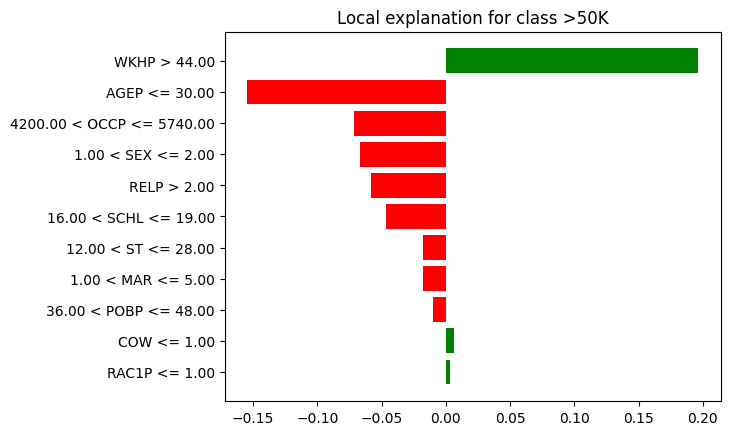

In [16]:
best_r2 = -np.inf
best_exp = None
best_sigma = None

for sigma in kernel_widths:
    explainer_sigma = LimeTabularExplainer( X_train_np, feature_names=feature_names, class_names=class_names,
        categorical_features=[X_train.columns.get_loc(col) for col in categorical_cols], discretize_continuous=True, mode='classification', kernel_width=sigma
    )
    
    exp = explainer_sigma.explain_instance(instance, rf_pipeline.predict_proba, num_features=len(feature_names))
    r2 = exp.score if hasattr(exp, "score") else None
    if r2 is not None and r2 > best_r2:
        best_r2 = r2
        best_exp = exp
        best_sigma = sigma

if best_exp is not None:
    print(f"Best local fidelity (R^2): {best_r2:.4f} with sigma = {best_sigma:.2f}") 
    print("OPTILIME explanation (feature, weight):")
    print(best_exp.as_list(label=1))
    best_exp.as_pyplot_figure(label=1)
    plt.show()
else:
    print("No valid explanation found.")

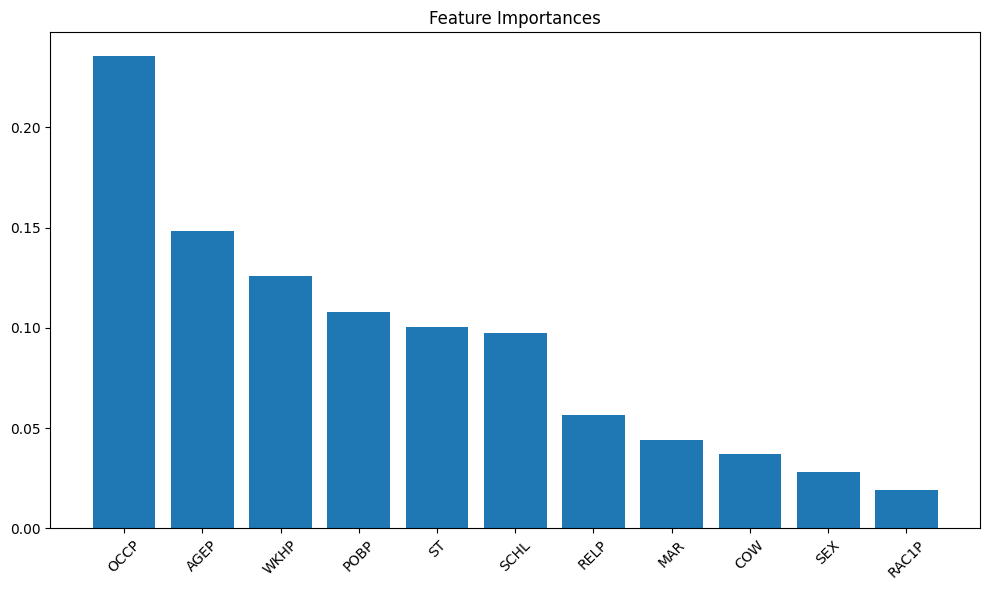

In [17]:
# Visualize feature importances from the Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(feature_names)), importances[indices], align="center")
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()


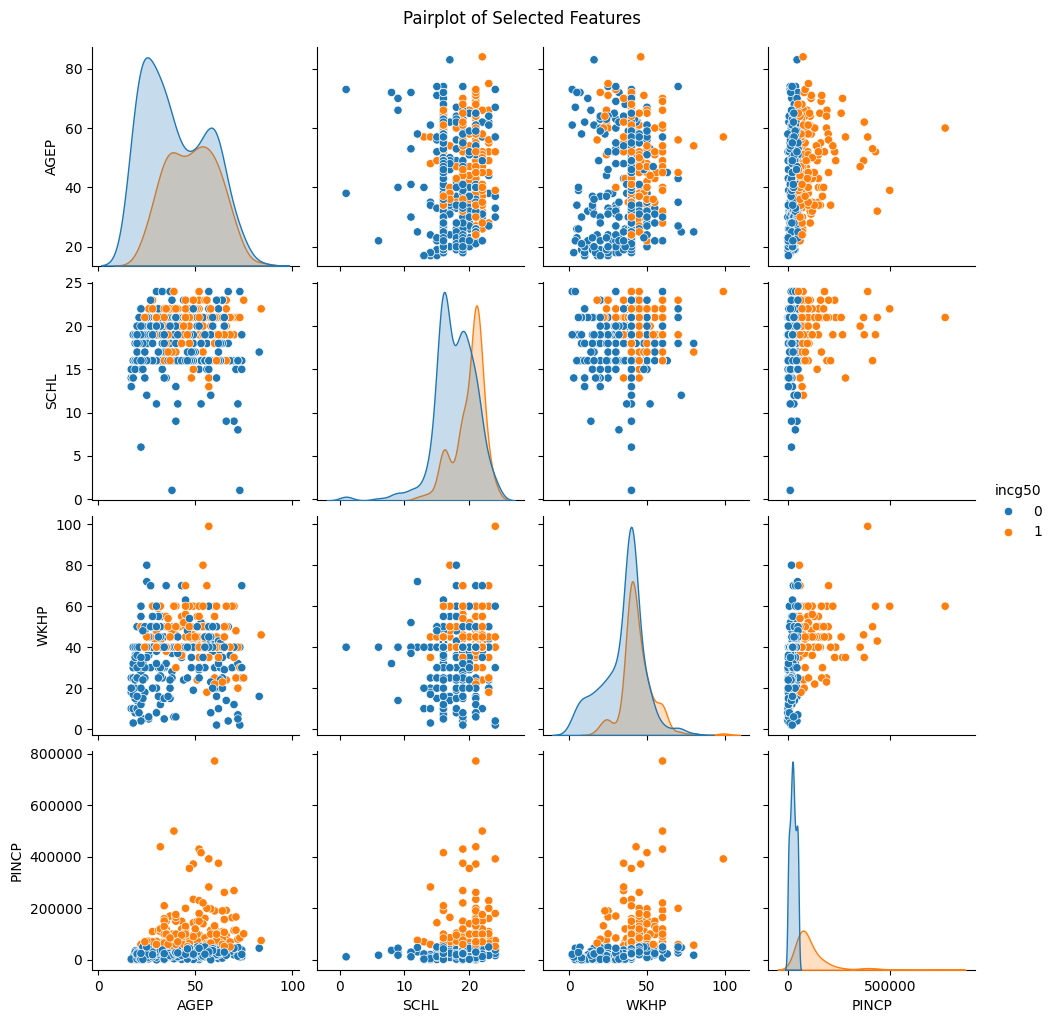

In [18]:
# Visualize a pairplot for a sample of the data
sample_df = df.sample(500, random_state=42)
sns.pairplot(sample_df, vars=['AGEP', 'SCHL', 'WKHP', 'PINCP'], hue='incg50', diag_kind='kde')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

d:\projects\Post-Hoc-Explainability\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


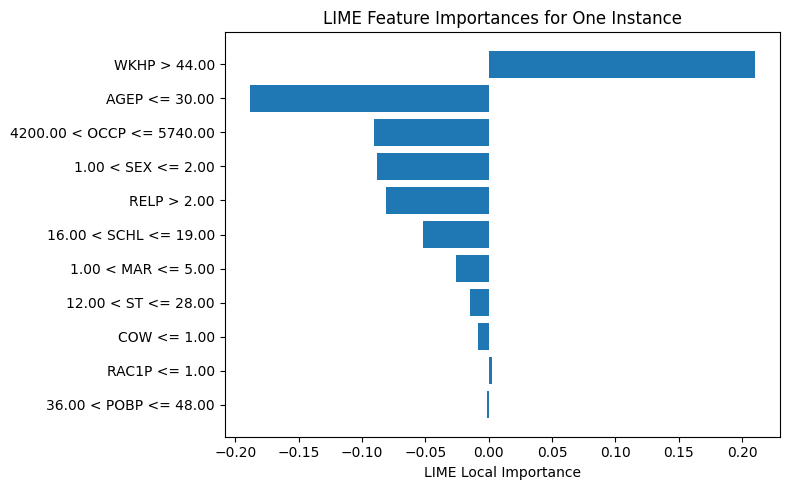

In [19]:

exp = explainer.explain_instance(instance, rf_pipeline.predict_proba, num_features=len(feature_names))

# Get feature importances as a list of (feature, weight)
lime_importances = exp.as_list(label=1)  # For class 1 (>50K)

# Convert to DataFrame for easier plotting
import pandas as pd
lime_df = pd.DataFrame(lime_importances, columns=['Feature', 'Importance'])
lime_df = lime_df.sort_values('Importance', key=abs, ascending=False)

# Plot LIME feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.barh(lime_df['Feature'], lime_df['Importance'])
plt.xlabel('LIME Local Importance')
plt.title('LIME Feature Importances for One Instance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
# ...existing code...

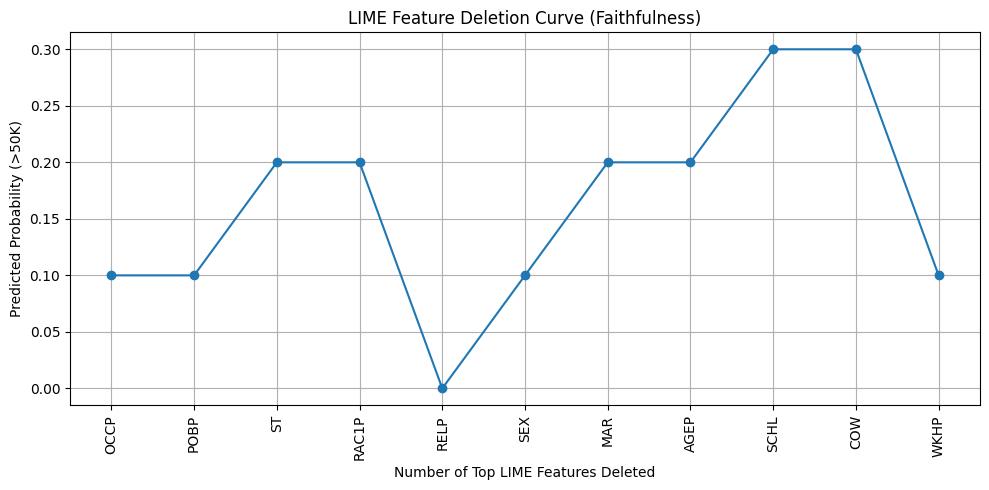

In [20]:
import random

def get_original_feature(lime_feat):
    # Find the first feature name that appears in the LIME string
    for feat in feature_names:
        if feat in lime_feat:
            return feat
    # Fallback: return the first word
    return lime_feat.split()[0]



ordered_features = [get_original_feature(feat) for feat, _ in sorted(lime_importances, key=lambda x: -abs(x[1]))]


seen = set()
ordered_features_unique = []
for f in ordered_features:
    
    if f not in seen and f in feature_names:
        ordered_features_unique.append(f)
        seen.add(f)
# Copy the instance to modify
random.shuffle(ordered_features_unique)
instance_df = pd.DataFrame([instance], columns=feature_names)
preds = []

for feat in ordered_features_unique:
    # Set the feature to its mean (numerical) or mode (categorical) from training data
    if feat in numerical_cols:
        instance_df[feat] = X_train[feat].mean()
    else:
        instance_df[feat] = X_train[feat].mode()[0]
    pred = rf_pipeline.predict_proba(instance_df)[0, 1]
    preds.append(pred)

# Plot the deletion curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(preds)+1), preds, marker='o')
plt.xlabel('Number of Top LIME Features Deleted')
plt.ylabel('Predicted Probability (>50K)')
plt.title('LIME Feature Deletion Curve (Faithfulness)')
plt.xticks(range(1, len(preds)+1), ordered_features_unique, rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
import numpy as np


perturbed_instance = instance.copy()
for idx, feat in enumerate(feature_names):
    if feat in numerical_cols:
        perturbed_instance[idx] += np.random.normal(0, 5)
        # 


exp_perturbed = explainer.explain_instance(perturbed_instance, rf_pipeline.predict_proba, num_features=len(feature_names))
lime_importances_perturbed = dict(exp_perturbed.as_list(label=1))
lime_importances_orig = dict(lime_importances)

# Get all LIME string features from both explanations
all_lime_feats = set(lime_importances_orig.keys()).union(lime_importances_perturbed.keys())

# Build aligned vectors
lime_vec_orig = np.array([lime_importances_orig.get(f, 0) for f in all_lime_feats])
lime_vec_pert = np.array([lime_importances_perturbed.get(f, 0) for f in all_lime_feats])

# Compute L2 norm (stability metric)
stability = np.linalg.norm(lime_vec_orig - lime_vec_pert)
print(f"LIME Stability : {stability:.4f}")


d:\projects\Post-Hoc-Explainability\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


LIME Stability : 0.2028


In [33]:
print(f"LIME Local Fidelity (R^2): {exp.score:.4f}")

LIME Local Fidelity (R^2): 0.3089
